# Quality Control and Preprocessing

## Objective

Establish a reproducible preprocessing pipeline with data-driven quality-control thresholds, and identify technical features of the dataset that could confound downstream inference.

## Data loading

In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "README.md").exists():
    if (PROJECT_ROOT.parent / "README.md").exists():
        PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
DATA_DIR.mkdir(parents=True, exist_ok=True)

adata = sc.read_h5ad(DATA_DIR / "srivatsan_2020_sciplex2.h5ad")
print("loaded from:", (DATA_DIR / "srivatsan_2020_sciplex2.h5ad").relative_to(PROJECT_ROOT))


loaded from: data\srivatsan_2020_sciplex2.h5ad


## Raw-count determination

Before normalization, `.X` was confirmed to hold raw UMI counts (integer values; row sums matching `ncounts`).

In [2]:
print("adata.raw =", adata.raw)
print("layers    =", list(adata.layers.keys()))

print("X type / dtype =", type(adata.X).__name__, adata.X.dtype)
d = adata.X.data                     # sparse-matrix non-zero values
print("X first 10 non-zero values =", d[:10])
print("X all integers？ =", bool(np.allclose(d, np.round(d))))
print("X value min/max  =", float(d.min()), float(d.max()))

rowsum = np.asarray(adata.X.sum(axis=1)).ravel()
print("row sums == obs.ncounts ?", bool(np.allclose(rowsum, adata.obs['ncounts'].values)))


adata.raw = None
layers    = []
X type / dtype = csr_matrix float32
X first 10 non-zero values = [1. 1. 3. 1. 1. 1. 2. 1. 1. 1.]


X all integers？ = True
X value min/max  = 1.0 5636.0
row sums == obs.ncounts ? True


## QC metrics

Per-cell total counts, detected genes, and mitochondrial fraction were computed. Recomputed metrics were cross-checked against the provider's precomputed columns.

In [3]:
print("species:", adata.obs['organism'].unique().tolist())

if (adata.obs['organism'] == 'human').all():
    prefix = 'MT-'          # human
else:
    prefix = 'mt-'          # mouse
adata.var['mt'] = adata.var_names.str.startswith(prefix)
print(f"mitochondrial genes ({prefix} prefix):", int(adata.var['mt'].sum()))

sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], inplace=True)

print("\ntotal_counts      == precomputed ncounts ?", bool(np.allclose(adata.obs['total_counts'].values, adata.obs['ncounts'].values)))
print("n_genes_by_counts  == precomputed ngenes  ?", bool(np.allclose(adata.obs['n_genes_by_counts'].values, adata.obs['ngenes'].values)))
mt_diff = np.abs(adata.obs['pct_counts_mt'].values - adata.obs['percent_mito'].values)
print("pct_counts_mt vs percent_mito max diff =", float(mt_diff.max()))


species: ['human']
mitochondrial genes (MT- prefix): 37



total_counts      == precomputed ncounts ? True
n_genes_by_counts  == precomputed ngenes  ? True
pct_counts_mt vs percent_mito max diff = 7.62939453125e-06


## QC visualization

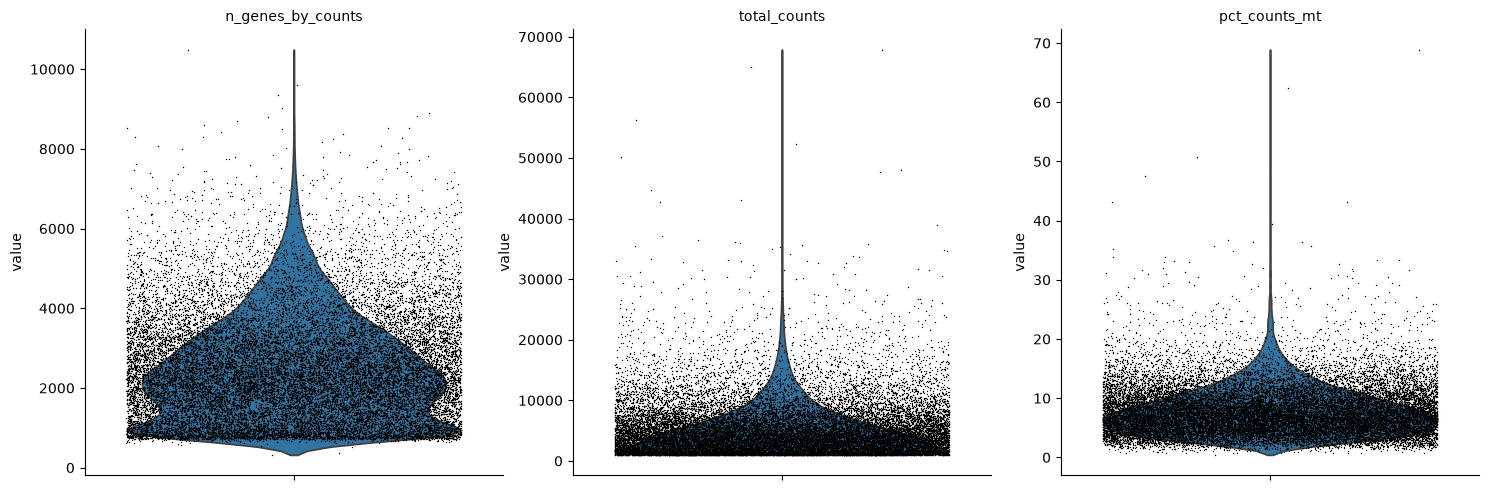

In [4]:
sc.pl.violin(adata, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],
             jitter=0.4, multi_panel=True, show=True)


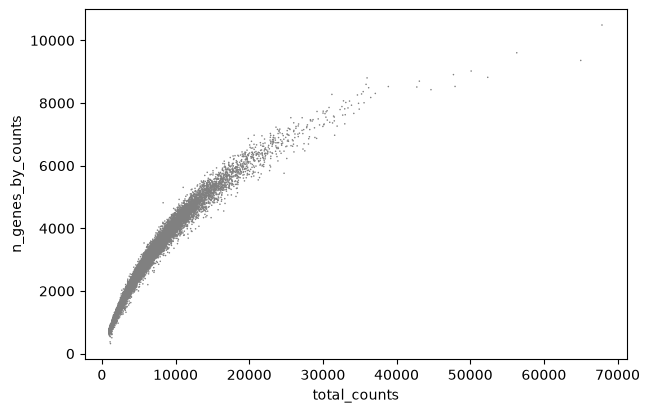

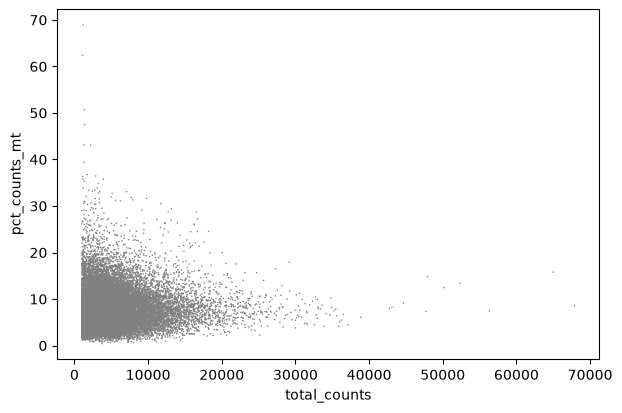

In [5]:
sc.pl.scatter(adata, x='total_counts', y='n_genes_by_counts', show=True)
sc.pl.scatter(adata, x='total_counts', y='pct_counts_mt', show=True)


## Treatment- and dose-specific QC

QC metrics were compared across perturbations and doses to check for condition-specific biases.

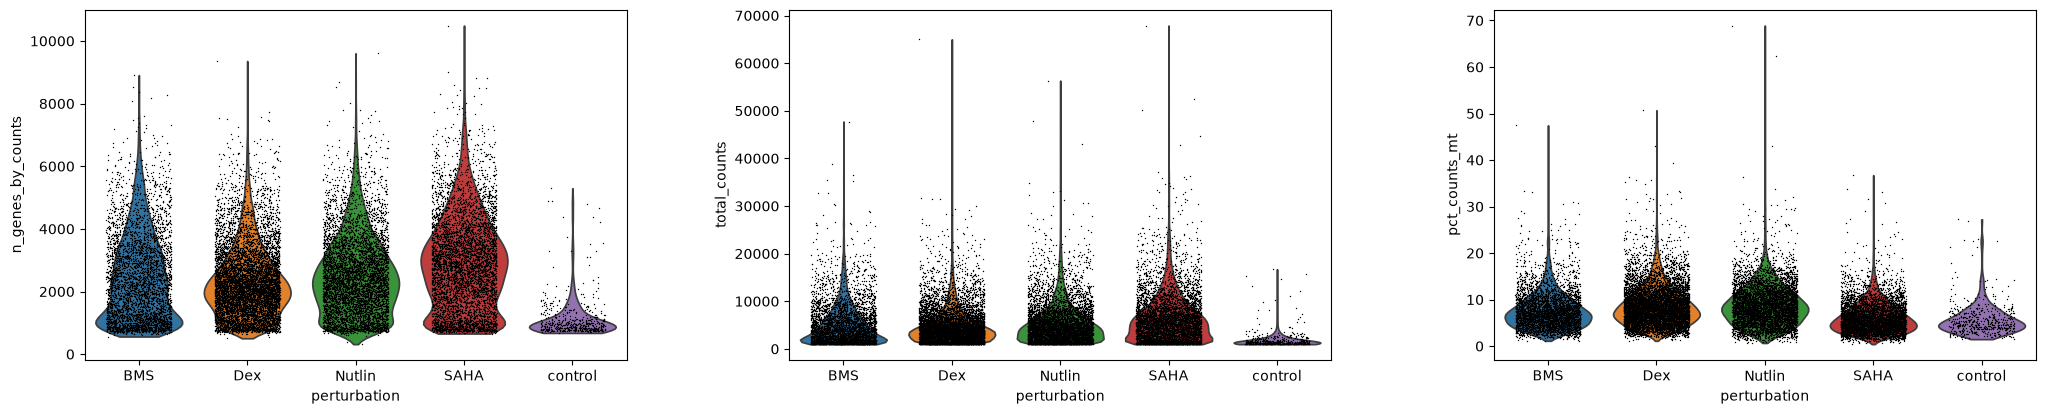

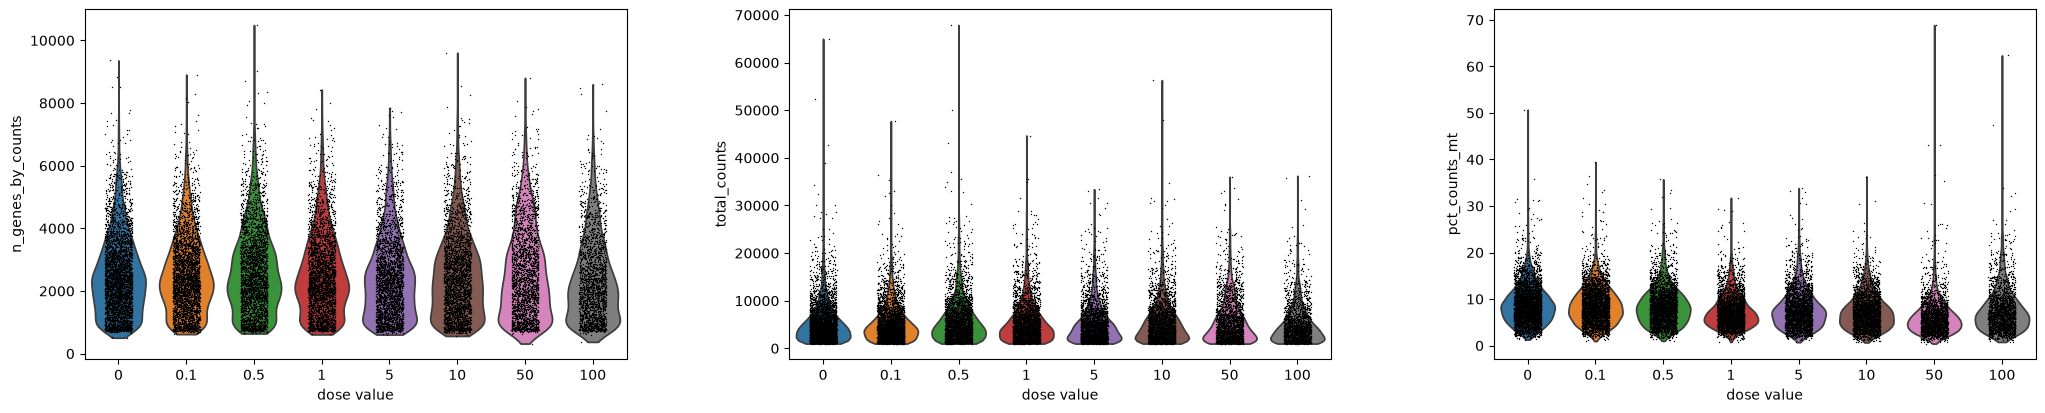

In [6]:
sc.pl.violin(adata, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],
             groupby='perturbation', jitter=0.3, multi_panel=True, show=True)

drug_cells = adata[adata.obs['perturbation'] != 'control'].copy()
sc.pl.violin(drug_cells, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],
             groupby='dose_value', jitter=0.2, multi_panel=True, show=True)


## Data-driven thresholds

Thresholds were selected from the observed distributions rather than generic defaults. The median mitochondrial fraction was approximately 7%, and a generic 5% cutoff would have removed a large fraction of cells. A distribution-informed, dataset-specific threshold was therefore used.

In [7]:
for col in ['n_genes_by_counts', 'total_counts', 'pct_counts_mt']:
    q = adata.obs[col].quantile([0, 0.01, 0.05, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99, 1.0])
    print(f"--- {col} ---")
    print(q.round(2).to_string())
    print()


--- n_genes_by_counts ---
0.00      321.00
0.01      729.00
0.05      802.00
0.25     1433.00
0.50     2280.00
0.75     3254.00
0.90     4287.90
0.95     4941.95
0.99     6304.56
1.00    10491.00

--- total_counts ---
0.00     1000.00
0.01     1023.00
0.05     1133.00
0.25     2306.25
0.50     4207.00
0.75     6943.00
0.90    10573.80
0.95    13418.65
0.99    20807.57
1.00    67886.00

--- pct_counts_mt ---
0.00     0.43
0.01     1.83
0.05     2.74
0.25     4.94
0.50     7.21
0.75    10.05
0.90    13.12
0.95    15.29
0.99    21.06
1.00    68.90



In [8]:
print("pct_mt > 20% :", round((adata.obs['pct_counts_mt'] > 20).mean() * 100, 2), "%")
print("pct_mt > 25% :", round((adata.obs['pct_counts_mt'] > 25).mean() * 100, 2), "%")
print("n_genes > 6000:", round((adata.obs['n_genes_by_counts'] > 6000).mean() * 100, 2), "%")
print("n_genes < 200 :", round((adata.obs['n_genes_by_counts'] < 200).mean() * 100, 2), "%")
print("total_counts < 1000:", round((adata.obs['total_counts'] < 1000).mean() * 100, 2), "%")


pct_mt > 20% : 1.22 %
pct_mt > 25% : 0.42 %
n_genes > 6000: 1.39 %
n_genes < 200 : 0.0 %
total_counts < 1000: 0.0 %


## Filtering

A distribution-informed mitochondrial threshold (< 20%) and a heuristic upper gene-count threshold (≤ 6,000, targeting high-complexity outliers / potential doublets; formal doublet detection was not performed) were applied.

In [9]:
n_cells_before = adata.n_obs
n_genes_before = adata.n_vars
obs_before = adata.obs.copy()
print(f"before filtering:{n_cells_before} cells, {n_genes_before} genes")

keep = (
    (adata.obs['n_genes_by_counts'] <= 6000) &   # upper bound: potential doublets
    (adata.obs['pct_counts_mt'] < 20)            # upper bound: high mitochondrial fraction
)
print("cells removed:", int((~keep).sum()))
adata = adata[keep, :].copy()

print(f"after filtering:{adata.n_obs} cells, {adata.n_vars} genes")


before filtering:24262 cells, 58347 genes
cells removed: 634


after filtering:23628 cells, 58347 genes


## Retention across conditions

In [10]:
ret_by_pert = pd.DataFrame({
    'cells_before': obs_before.groupby('perturbation', observed=True).size(),
    'cells_after':  adata.obs.groupby('perturbation', observed=True).size(),
})
ret_by_pert['pct_retained'] = (ret_by_pert['cells_after'] / ret_by_pert['cells_before'] * 100).round(1)
ret_by_pert


,cells_before,cells_after,pct_retained
perturbation,,,
BMS,4183,4060,97.1
Dex,8064,7884,97.8
Nutlin,5956,5806,97.5
SAHA,5530,5357,96.9
control,529,521,98.5


In [11]:
is_drug = obs_before['perturbation'] != 'control'
ret_by_dose = pd.DataFrame({
    'cells_before': obs_before[is_drug].groupby('dose_value', observed=True).size(),
    'cells_after':  adata.obs[adata.obs['perturbation'] != 'control'].groupby('dose_value', observed=True).size(),
})
ret_by_dose['pct_retained'] = (ret_by_dose['cells_after'] / ret_by_dose['cells_before'] * 100).round(1)
ret_by_dose


,cells_before,cells_after,pct_retained
dose_value,,,
0,3901,3804,97.5
0.1,3479,3399,97.7
0.5,3094,2987,96.5
1,3119,3050,97.8
5,2828,2756,97.5
10,2832,2766,97.7
50,2433,2364,97.2
100,2047,1981,96.8


In [12]:
well_before = obs_before.groupby('well', observed=True).size()
well_after  = adata.obs.groupby('well', observed=True).size()
well_ret = (well_after / well_before * 100)
print("192  wells retention min / median / max =",
      round(well_ret.min(), 1), "/", round(well_ret.median(), 1), "/", round(well_ret.max(), 1))
print("retention < 90%  well count:", int((well_ret < 90).sum()))


192  wells retention min / median / max = 80.0 / 97.6 / 100.0
retention < 90%  well count: 3


## Raw-count preservation

Raw counts were retained for count-based pseudobulk differential-expression analysis and reproducibility.

In [13]:
adata.layers['counts'] = adata.X.copy()
print("layers keys:", list(adata.layers.keys()))


layers keys: ['counts']


## Normalization and log transformation

In [14]:
sc.pp.normalize_total(adata, target_sum=1e4)
print("post-normalize_total mean per-cell sum (≈10000):",
      round(float(np.asarray(adata.X.sum(axis=1)).ravel().mean()), 1))

sc.pp.log1p(adata)
print("post-log1p .X range:", round(float(adata.X.min()), 4), "-", round(float(adata.X.max()), 4))


post-normalize_total mean per-cell sum (≈10000): 10000.0


post-log1p .X range: 0.0 - 7.6084


## Highly variable genes

In [15]:
sc.pp.highly_variable_genes(adata, n_top_genes=2000)
print("HVG count:", int(adata.var['highly_variable'].sum()))
print("\ntop 5 HVGs (by normalized dispersion dispersions_norm descending):")
hvg = adata.var[adata.var['highly_variable']].sort_values('dispersions_norm', ascending=False)
hvg.head(5)[['means', 'dispersions_norm']]


HVG count: 2000

top 5 HVGs (by normalized dispersion dispersions_norm descending):


,means,dispersions_norm
gene_symbol,,
SORCS1,0.714804,11.267818
SCUBE3,0.366635,10.892810
AC115622.1,0.779882,10.568823
TENM1,0.583934,10.168375
AC092650.1,1.182369,9.981251


## Save

In [16]:
out_dir = DATA_DIR / "processed"
out_dir.mkdir(parents=True, exist_ok=True)
adata.write_h5ad(out_dir / "adata_preprocessed.h5ad")
print("saved to:", (out_dir / "adata_preprocessed.h5ad").relative_to(PROJECT_ROOT))


saved to: data\processed\adata_preprocessed.h5ad


## QC Summary

- 634 cells (2.6%) removed; 23,628 cells retained across 58,347 genes.
- Retention was balanced across treatment groups (≈ 97–98.5%).
- Raw counts preserved in `layers['counts']`; normalized expression in `.X`.

## Technical Considerations

- The un-hashed control population showed substantially lower sequencing depth than treated samples, suggesting a technical difference associated with its distinct processing scheme; it was therefore not used as the primary baseline for downstream contrasts.
- QC thresholds were dataset-specific rather than transferred from generic pipelines.